# Test 5: Per-Source Accuracy Breakdown

**Goal**: Evaluate the GraphCodeBERT model separately on each dataset source  
(Devign / Draper / LVDAndro / Juliet) using only the held-out test split.

**Method**: Filter test-set samples by `filename` prefix (e.g. `Devign_`, `Draper_`, etc.)  
then run inference group-by-group.

**Output**: `test5_per_source_results.txt`, `test5_per_source_bar.png`

> ⚠️ We do NOT use the CodeXGLUE Devign split — our model trained on sampled Devign rows  
> so we filter exclusively from our own held-out test set to avoid data leakage.

In [1]:
!pip install -q torch transformers scikit-learn matplotlib

In [2]:
import os, json, random, numpy as np, torch

class Args:
    # ── Paths ─────────────────────────────────────────────────────────
    model_name_or_path = 'microsoft/graphcodebert-base'
    tokenizer_name     = 'microsoft/graphcodebert-base'
    train_file         = '/kaggle/input/datasets/hasanmahmudabdullah/dfgdataset2/dataset_graphcodebert.jsonl'
    model_weights      = '/kaggle/input/notebooks/hasanmahmudabdullah2/graphcodebert-v2-training/saved_models/model.bin'  # ← update path
    # ── Split config (must match original training split) ────────────
    test_size          = 0.10    
    val_size           = 0.00    
    seed               = 42
    # ── Model ────────────────────────────────────────────────────────
    block_size         = 512
    code_length        = 384
    data_flow_length   = 128
    eval_batch_size    = 16
    device             = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

args = Args()

# Source prefixes → labels for the table
SOURCES = {
    'Devign'   : 'Devign (C/C++ — QEMU/FFmpeg)',
    'Draper'   : 'Draper (C/C++ — NVD/SARD)',
    'LVDAndro' : 'LVDAndro (Android Java/C)',
    'Juliet'   : 'Juliet Test Suite (Synthetic C/C++)',
}

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(args.seed)
print(f'Device : {args.device}')
print(f'Sources: {list(SOURCES.keys())}')

Device : cuda
Sources: ['Devign', 'Draper', 'LVDAndro', 'Juliet']


In [3]:
import torch
import torch.nn as nn
from transformers import RobertaConfig, RobertaModel, AutoTokenizer

class Model(nn.Module):
    def __init__(self, encoder, config, tokenizer, args):
        super().__init__()
        self.encoder    = encoder
        self.config     = config
        self.tokenizer  = tokenizer
        self.classifier = nn.Linear(config.hidden_size, 2)
        self.dropout    = nn.Dropout(0.1)

    def forward(self, input_ids=None, position_ids=None, attn_mask=None, labels=None):
        bs   = input_ids.shape[0]
        inp  = input_ids.view(bs, -1)
        pos  = position_ids.view(bs, -1)
        mask = attn_mask.view(bs, inp.shape[1], -1)
        outputs = self.encoder(
            input_ids      = inp,
            position_ids   = pos,
            attention_mask = mask[:, 0, :],
        )
        sequence_output = outputs[0]
        logits = self.classifier(self.dropout(sequence_output[:, 0, :]))
        if labels is not None:
            loss = nn.CrossEntropyLoss()(logits, labels)
            return loss, logits
        return logits

In [4]:
import torch
from torch.utils.data import Dataset

def _safe_token_idx(val):
    if isinstance(val, int): return val
    if isinstance(val, list):
        if val and isinstance(val[0], int): return val[0]
    return None

class TextDataset(Dataset):
    def __init__(self, tokenizer, args, file_path, indices=None):
        self.tokenizer = tokenizer
        self.args = args
        with open(file_path, encoding='utf-8') as f:
            all_lines = f.readlines()
        self.lines = [all_lines[i] for i in indices] if indices is not None else all_lines

    def __len__(self): return len(self.lines)

    def __getitem__(self, i):
        js = json.loads(self.lines[i].strip())
        return self._convert(js, self.tokenizer, self.args)

    def _convert(self, js, tokenizer, args):
        code  = js['code']
        label = int(js.get('label', 0))
        dfg   = js.get('dfg', [])[:args.data_flow_length]

        code_tokens = tokenizer.tokenize(code)[:args.code_length - 2]
        code_tokens = [tokenizer.cls_token] + code_tokens + [tokenizer.sep_token]
        code_ids    = tokenizer.convert_tokens_to_ids(code_tokens)
        pad_len     = args.code_length - len(code_ids)
        code_ids   += [tokenizer.pad_token_id] * pad_len
        position_idx = list(range(len(code_tokens))) + [tokenizer.pad_token_id] * pad_len

        dfg_to_code = {}
        for i, d in enumerate(dfg):
            idx = _safe_token_idx(d[1] if len(d) > 1 else 0)
            if idx is not None:
                dfg_to_code[i] = idx

        dfg_ids  = [tokenizer.convert_tokens_to_ids(
                        tokenizer.tokenize(str(d[0]))[:1] or [tokenizer.unk_token]
                    )[0] for d in dfg]
        pad_dfg  = args.data_flow_length - len(dfg_ids)
        dfg_ids += [tokenizer.pad_token_id] * pad_dfg
        dfg_pos  = [args.code_length + i for i in range(len(dfg))] + [0] * pad_dfg

        attn = np.zeros((args.block_size, args.block_size), dtype=np.int64)
        attn[:len(code_tokens), :len(code_tokens)] = 1
        for i, d in enumerate(dfg):
            attn[args.code_length + i, args.code_length + i] = 1
            code_idx = dfg_to_code.get(i)
            if code_idx is not None and code_idx < len(code_tokens):
                attn[args.code_length + i, code_idx] = 1
                attn[code_idx, args.code_length + i] = 1
            for j in (d[4] if len(d) > 4 and isinstance(d[4], list) else []):
                if isinstance(j, int) and j < len(dfg):
                    attn[args.code_length + i, args.code_length + j] = 1

        return (
            torch.tensor(code_ids + dfg_ids,         dtype=torch.long),
            torch.tensor(position_idx + dfg_pos,     dtype=torch.long),
            torch.tensor(attn,                       dtype=torch.long),
            torch.tensor(label,                      dtype=torch.long),
        )

In [5]:
from transformers import RobertaConfig, RobertaModel, AutoTokenizer

config    = RobertaConfig.from_pretrained(args.model_name_or_path)
config.num_labels = 2
tokenizer = AutoTokenizer.from_pretrained(args.tokenizer_name)
encoder   = RobertaModel.from_pretrained(args.model_name_or_path, config=config)
model     = Model(encoder, config, tokenizer, args).to(args.device)

print(f'Loading weights from: {args.model_weights}')
state = torch.load(args.model_weights, map_location=args.device)
model.load_state_dict(state, strict=False)
model.eval()
print('  ✓ Model ready')

config.json:   0%|          | 0.00/539 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/772 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: microsoft/graphcodebert-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.decoder.weight          | UNEXPECTED | 
lm_head.decoder.bias            | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
pooler.dense.bias               | MISSING    | 
pooler.dense.weight             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights from: /kaggle/input/notebooks/hasanmahmudabdullah2/graphcodebert-v2-training/saved_models/model.bin
  ✓ Model ready


In [6]:
from sklearn.model_selection import train_test_split

# Read all lines and record filename prefix per index
print(f'Reading dataset: {args.train_file}')
with open(args.train_file, encoding='utf-8') as f:
    all_lines = f.readlines()

n_total = len(all_lines)
print(f'  Total samples: {n_total:,}')

# Replicate the exact same split as training
all_idx = list(range(n_total))
train_idx, test_idx = train_test_split(all_idx, test_size=0.10,
                                        random_state=42)
print(f'  Test set size : {len(test_idx):,}')

# Build filename → source lookup for the test set
test_source_map = {}   # idx -> source_prefix
for idx in test_idx:
    js = json.loads(all_lines[idx].strip())
    fn = js.get('filename', '')
    # filename is like 'Devign_0_file', 'LVDAndro_1_file' etc.
    source = fn.split('_')[0] if fn else 'Unknown'
    test_source_map[idx] = source

# Count per source
from collections import Counter
counts = Counter(test_source_map.values())
print()
print('Test-set sample counts per source:')
for src, n in sorted(counts.items()):
    print(f'  {src:12s}: {n:,}')

Reading dataset: /kaggle/input/datasets/hasanmahmudabdullah/dfgdataset2/dataset_graphcodebert.jsonl
  Total samples: 199,960
  Test set size : 19,996

Test-set sample counts per source:
  Devign      : 2,477
  Draper      : 7,449
  Juliet      : 2,533
  LVDAndro    : 7,537


In [7]:
from torch.utils.data import DataLoader
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, roc_auc_score
from tqdm import tqdm

def evaluate_subset(model, indices, args, label=''):
    ds     = TextDataset(tokenizer, args, args.train_file, indices=indices)
    loader = DataLoader(ds, batch_size=args.eval_batch_size, shuffle=False)

    all_preds, all_labels, all_probs = [], [], []

    with torch.no_grad():
        for batch in tqdm(loader, desc=f'Eval ({label})', leave=False):
            ids, pos, mask, lbl = [b.to(args.device) for b in batch]
            logits = model(input_ids=ids, position_ids=pos, attn_mask=mask)
            probs  = torch.softmax(logits, dim=-1)[:, 1].cpu().numpy()
            preds  = logits.argmax(dim=-1).cpu().numpy()
            all_preds .extend(preds)
            all_labels.extend(lbl.cpu().numpy())
            all_probs .extend(probs)

    acc = accuracy_score(all_labels, all_preds)
    prec, rec, f1, _ = precision_recall_fscore_support(
        all_labels, all_preds, average='macro', zero_division=0)
    try:
        auc = roc_auc_score(all_labels, all_probs)
    except Exception:
        auc = float('nan')

    fn = sum(1 for p, l in zip(all_preds, all_labels) if l == 1 and p == 0)
    return acc, prec, rec, f1, auc, fn, len(indices)


print('Running per-source evaluation on test set...\n')
results = {}

for prefix, label in SOURCES.items():
    src_indices = [idx for idx, src in test_source_map.items() if src == prefix]
    if not src_indices:
        print(f'  ⚠ No test samples found for source: {prefix}')
        continue
    torch.cuda.empty_cache()   # ← add this
    import gc; gc.collect()  
    
    print(f'  Evaluating {prefix} ({len(src_indices):,} samples)...')
    acc, prec, rec, f1, auc, fn, n = evaluate_subset(model, src_indices, args, prefix)
    results[prefix] = dict(label=label, acc=acc, prec=prec, rec=rec,
                           f1=f1, auc=auc, fn=fn, n=n)
    print(f'    Acc={acc:.4%}  ROC-AUC={auc:.4f}  F1={f1:.4f}  FN={fn}')

print('\nAll sources done!')

Running per-source evaluation on test set...

  Evaluating Devign (2,477 samples)...


Eval (Devign):   0%|          | 0/155 [00:00<?, ?it/s]Token indices sequence length is longer than the specified maximum sequence length for this model (2543 > 512). Running this sequence through the model will result in indexing errors


    Acc=67.5818%  ROC-AUC=0.7633  F1=0.6746  FN=449
  Evaluating Draper (7,449 samples)...


    Acc=89.4348%  ROC-AUC=0.9507  F1=0.8943  FN=439
  Evaluating LVDAndro (7,537 samples)...


    Acc=98.3415%  ROC-AUC=0.9978  F1=0.9834  FN=51
  Evaluating Juliet (2,533 samples)...


    Acc=100.0000%  ROC-AUC=1.0000  F1=1.0000  FN=0

All sources done!


In [8]:
line = '=' * 72
print(line)
print('PER-SOURCE ACCURACY BREAKDOWN (paper-ready table)')
print(line)
print(f'{"Source":<22} {"N":>7}  {"Accuracy":>10}  {"ROC-AUC":>10}  {"F1":>8}  {"FN":>6}')
print('-' * 72)

for prefix, R in results.items():
    print(f'{prefix:<22} {R["n"]:>7,}  {R["acc"]:>10.4%}  {R["auc"]:>10.4f}  {R["f1"]:>8.4f}  {R["fn"]:>6}')

print(line)

# Overall (aggregate all test samples)
all_accs = [R['acc'] for R in results.values()]
all_aucs = [R['auc'] for R in results.values()]
all_f1s  = [R['f1']  for R in results.values()]
print(f'Macro mean across sources: Acc={np.mean(all_accs):.4%}  AUC={np.nanmean(all_aucs):.4f}  F1={np.mean(all_f1s):.4f}')

PER-SOURCE ACCURACY BREAKDOWN (paper-ready table)
Source                       N    Accuracy     ROC-AUC        F1      FN
------------------------------------------------------------------------
Devign                   2,477    67.5818%      0.7633    0.6746     449
Draper                   7,449    89.4348%      0.9507    0.8943     439
LVDAndro                 7,537    98.3415%      0.9978    0.9834      51
Juliet                   2,533   100.0000%      1.0000    1.0000       0
Macro mean across sources: Acc=88.8395%  AUC=0.9280  F1=0.8881


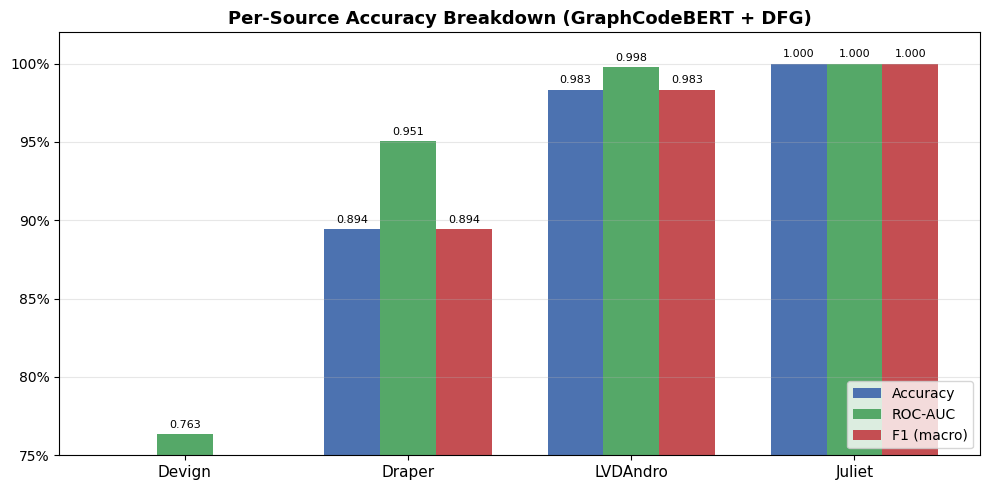

Bar chart saved → /kaggle/working/test5_per_source_bar.png


In [9]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

sources  = list(results.keys())
accs     = [results[s]['acc']  for s in sources]
aucs     = [results[s]['auc']  for s in sources]
f1s      = [results[s]['f1']   for s in sources]

x     = range(len(sources))
width = 0.25
colors = ['#4C72B0', '#55A868', '#C44E52']

fig, ax = plt.subplots(figsize=(10, 5))
b1 = ax.bar([i - width for i in x], accs, width, label='Accuracy',  color=colors[0])
b2 = ax.bar([i         for i in x], aucs, width, label='ROC-AUC',   color=colors[1])
b3 = ax.bar([i + width for i in x], f1s,  width, label='F1 (macro)',color=colors[2])

for bar in [b1, b2, b3]:
    for rect in bar:
        h = rect.get_height()
        ax.annotate(f'{h:.3f}',
                    xy=(rect.get_x() + rect.get_width() / 2, h),
                    xytext=(0, 3), textcoords='offset points',
                    ha='center', va='bottom', fontsize=8)

ax.set_xticks(list(x))
ax.set_xticklabels(sources, fontsize=11)
ax.set_ylim(0.75, 1.02)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
ax.set_title('Per-Source Accuracy Breakdown (GraphCodeBERT + DFG)', fontsize=13, fontweight='bold')
ax.legend(loc='lower right')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
out_path = '/kaggle/working/test5_per_source_bar.png'
plt.savefig(out_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Bar chart saved → {out_path}')

In [10]:
out_txt = '/kaggle/working/test5_per_source_results.txt'
with open(out_txt, 'w') as f:
    f.write('PER-SOURCE ACCURACY BREAKDOWN\n')
    f.write('=' * 72 + '\n')
    f.write(f'{"Source":<22} {"N":>7}  {"Accuracy":>10}  {"ROC-AUC":>10}  {"F1":>8}  {"FN":>6}\n')
    f.write('-' * 72 + '\n')
    for prefix, R in results.items():
        f.write(f'{prefix:<22} {R["n"]:>7,}  {R["acc"]:>10.4%}  {R["auc"]:>10.4f}  {R["f1"]:>8.4f}  {R["fn"]:>6}\n')
    f.write('=' * 72 + '\n')
    f.write(f'Macro mean across sources: Acc={np.mean(all_accs):.4%}  AUC={np.nanmean(all_aucs):.4f}  F1={np.mean(all_f1s):.4f}\n')

print(f'Results saved  → {out_txt}')
print(f'Bar chart      → /kaggle/working/test5_per_source_bar.png')

Results saved  → /kaggle/working/test5_per_source_results.txt
Bar chart      → /kaggle/working/test5_per_source_bar.png
